In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# ==========================================
# ETAP 1 & 2: WCZYTANIE I PRZYGOTOWANIE DANYCH
# ==========================================

DATASET_PATH = "data/PIoT_fault_dataset.csv"

if os.path.exists(DATASET_PATH):
    print(f"Wczytywanie zbioru danych: {DATASET_PATH}")
    df = pd.read_csv(DATASET_PATH)
else:
    print(f"Nie znaleziono pliku '{DATASET_PATH}'.")
    exit()

# Wyświetlenie podstawowych informacji o strukturze danych
print("\n--- Podgląd danych (Pierwsze 5 wierszy) ---")
print(df.head())

print("\n--- Rozkład klas usterek w zbiorze ---")
print(df["Fault_Label"].value_counts(normalize=True) * 100)

# Sprawdzenie braków danych:
print("\n--- Sprawdzenie czy dane zawierają brakujące wartości (NaN) ---")
print(df.isna().sum())

if df.isna().sum().sum() != 0:
    # Czyszczenie danych: usunięcie wierszy z brakami (NaN)
    df = df.dropna()

# Podział na cechy (X) oraz etykietę usterki (y)
target_column = "Fault_Label"
X = df.drop(columns=[target_column])
y = df[target_column]

Wczytywanie zbioru danych: data/PIoT_fault_dataset.csv

--- Podgląd danych (Pierwsze 5 wierszy) ---
   Timestamp  Node_ID     Voltage    Current  Frequency      Power  \
0          0        7  237.987383  11.186337  50.070573  26.622071   
1          1       20  227.526770   8.176694  50.039255  18.604167   
2          2       29  221.099374   7.525063  50.084475  16.637867   
3          3       15  221.757548   7.725553  50.103033  17.131996   
4          4       11  223.082223  11.021295  50.099417  24.586549   

   Temperature      Load  Fault_Label  
0    30.124274  0.525255            0  
1    37.414614  0.612410            0  
2    35.471717  0.701497            0  
3    39.171222  0.709043            0  
4    34.394708  0.779392            0  

--- Rozkład klas usterek w zbiorze ---
Fault_Label
0    96.394709
3     2.212338
1     1.392953
Name: proportion, dtype: float64

--- Sprawdzenie czy dane zawierają brakujące wartości (NaN) ---
Timestamp      0
Node_ID        0
Voltage   

In [3]:

# ==========================================
# ETAP 3: PODZIAŁ NA ZBIÓR TRENINGOWY I TESTOWY
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standaryzacja cech (Skalowanie)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:

# ==========================================
# ETAP 4: TRENOWANIE MODELU (LAS LOSOWY)
# ==========================================
print("\nRozpoczynanie trenowania modelu Random Forest Classifier...")
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
model.fit(X_train_scaled, y_train)
print("Model został pomyślnie wytrenowany!")


Rozpoczynanie trenowania modelu Random Forest Classifier...
Model został pomyślnie wytrenowany!



--- RAPORT KLASYFIKACJI ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1647
           1       1.00      0.96      0.98        24
           3       0.97      0.95      0.96        38

    accuracy                           1.00      1709
   macro avg       0.99      0.97      0.98      1709
weighted avg       1.00      1.00      1.00      1709



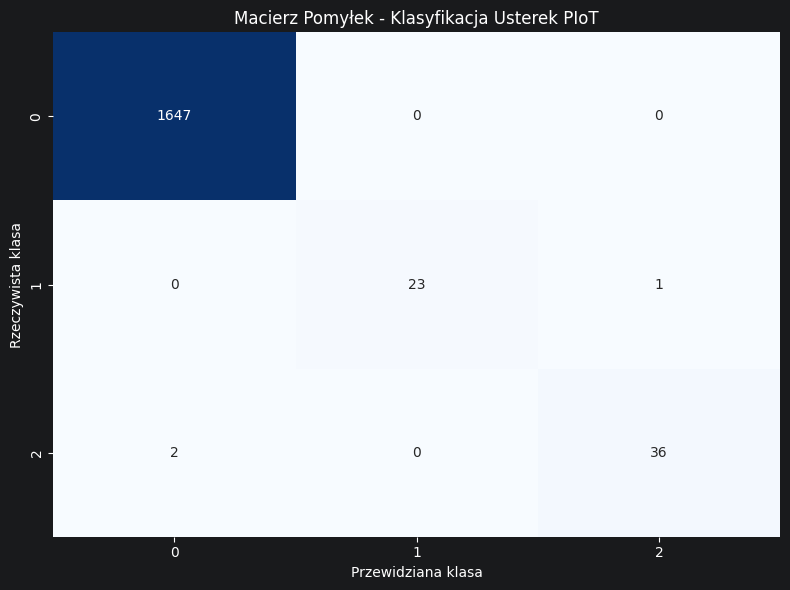

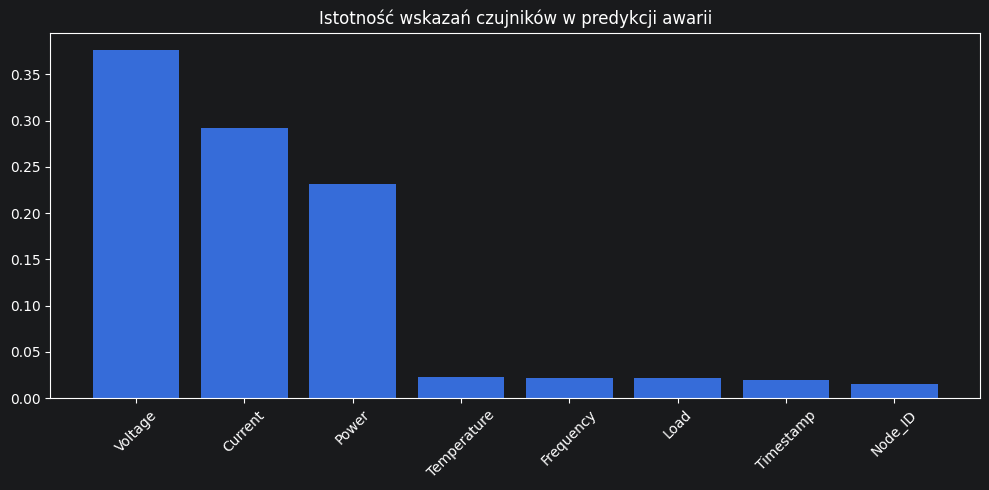

In [5]:

# ==========================================
# ETAP 5: EWALUACJA MODELU
# ==========================================
y_pred = model.predict(X_test_scaled)

print("\n--- RAPORT KLASYFIKACJI ---")
print(classification_report(y_test, y_pred))

# Generowanie i wizualizacja Macierzy Pomyłek (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Macierz Pomyłek - Klasyfikacja Usterek PIoT")
plt.xlabel("Przewidziana klasa")
plt.ylabel("Rzeczywista klasa")
plt.tight_layout()
plt.show()

# Istotność cech (Feature Importance) - informacja, które sensory są kluczowe dla wykrywania awarii
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Istotność wskazań czujników w predykcji awarii")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()